# Member 2 — Dataset Description Notebook
## CCS3356 Natural Language Processing | Fake News Detection
### Student ID: CIT-24-01-0486

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load both CSV files
fake = pd.read_csv('../data/Fake.csv')
true = pd.read_csv('../data/True.csv')

# Add label column — 1 = Fake, 0 = Real
fake['label'] = 1
true['label'] = 0

print(f"Fake news articles: {len(fake)}")
print(f"Real news articles: {len(true)}")
print(f"Total articles: {len(fake) + len(true)}")

Fake news articles: 23481
Real news articles: 21417
Total articles: 44898


In [4]:
# Merge into one dataframe
df = pd.concat([fake, true], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

First 5 rows:


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [5]:
print("Dataset Info:")
print("-" * 40)
df.info()
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [6]:
print("Class Distribution:")
print("-" * 40)
print(df['label'].value_counts())
print(f"\nFake: {df['label'].value_counts()[1]} ({df['label'].value_counts(normalize=True)[1]*100:.1f}%)")
print(f"Real: {df['label'].value_counts()[0]} ({df['label'].value_counts(normalize=True)[0]*100:.1f}%)")

Class Distribution:
----------------------------------------
label
1    23481
0    21417
Name: count, dtype: int64

Fake: 23481 (52.3%)
Real: 21417 (47.7%)


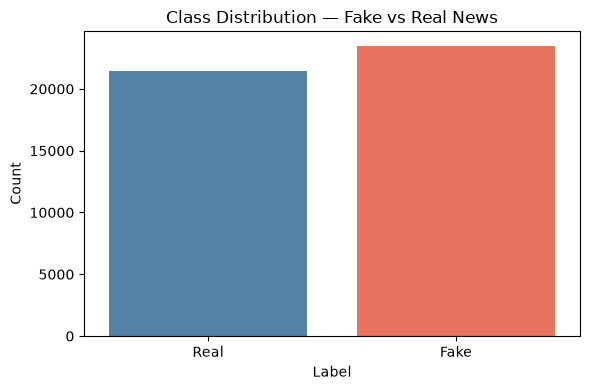

Chart saved to screenshots/


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Real', 'Fake'])
plt.title('Class Distribution — Fake vs Real News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png')
plt.show()
print("Chart saved to screenshots/")

In [8]:
print("Sample FAKE articles:")
display(df[df['label']==1][['title','subject','label']].head(3))

print("\nSample REAL articles:")
display(df[df['label']==0][['title','subject','label']].head(3))

Sample FAKE articles:


,title,subject,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,US_News,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,News,1
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,News,1



Sample REAL articles:


,title,subject,label
1,Trump drops Steve Bannon from National Securit...,politicsNews,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,politicsNews,0
4,Donald Trump heads for Scotland to reopen a go...,politicsNews,0


In [9]:
# Save merged dataset for use by all members
df.to_csv('../data/merged.csv', index=False)
print("Merged dataset saved to data/merged.csv")
print(f"Total records saved: {len(df)}")

Merged dataset saved to data/merged.csv
Total records saved: 44898
